# 03 — Transformation (data refinement)

## Objectif
Créer des colonnes utiles pour l’analyse temporelle (par mois, jour, etc.)
et produire une donnée finale exploitable.

### Transformations choisies
- Extraire l’année, le mois, le nom du mois, le jour, le nom du jour à partir de Transaction Date
- Créer une table d’analyse : chiffre d’affaires par mois
- Vérifier la qualité finale (pas de dates manquantes, pas de valeurs négatives)

In [2]:
import pandas as pd
import numpy as np

clean_file_path = "../DATA/PROCESSED/clean_cafe_sales.csv"
sales_data = pd.read_csv(clean_file_path)

print("Dataset chargé (lignes, colonnes) :", sales_data.shape)
sales_data.head(5)

Dataset chargé (lignes, colonnes) : (7773, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,In-store,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
sales_data["Transaction Date"] = pd.to_datetime(sales_data["Transaction Date"], errors="coerce")

print("Dates manquantes :", sales_data["Transaction Date"].isna().sum())

Dates manquantes : 0


In [4]:
sales_data["Year"] = sales_data["Transaction Date"].dt.year
sales_data["Month"] = sales_data["Transaction Date"].dt.month
sales_data["Month Name"] = sales_data["Transaction Date"].dt.month_name()

sales_data["Day"] = sales_data["Transaction Date"].dt.day
sales_data["Day Name"] = sales_data["Transaction Date"].dt.day_name()

sales_data.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day,Day Name
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,8,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,16,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,19,Wednesday
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,In-store,2023-04-27,2023,4,April,27,Thursday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,11,Sunday


In [5]:
monthly_revenue = sales_data.groupby(["Year", "Month"])["Total Spent"].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(["Year", "Month"])

monthly_revenue

,Year,Month,Total Spent
0,2023,1,5944.0
1,2023,2,5421.0
2,2023,3,5879.0
3,2023,4,5835.0
4,2023,5,5568.0
5,2023,6,6005.0
6,2023,7,5737.5
7,2023,8,5746.0
8,2023,9,5617.0
9,2023,10,6032.0


Matplotlib is building the font cache; this may take a moment.


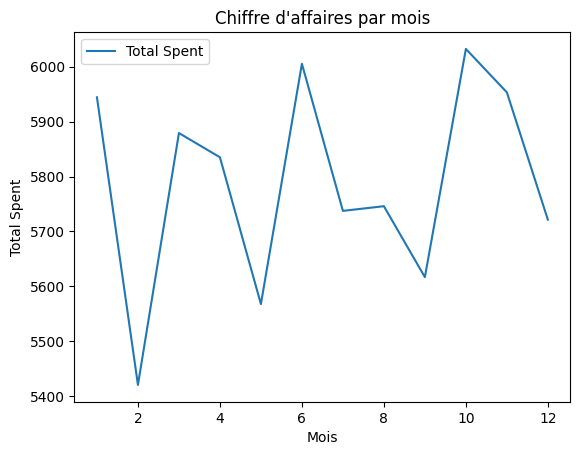

In [6]:
import matplotlib.pyplot as plt

monthly_revenue.plot(x="Month", y="Total Spent", kind="line")
plt.title("Chiffre d'affaires par mois")
plt.xlabel("Mois")
plt.ylabel("Total Spent")
plt.show()

In [7]:
print("Manquants totaux :", sales_data.isna().sum().sum())
print("Dates manquantes :", sales_data["Transaction Date"].isna().sum())

print("Quantité min :", sales_data["Quantity"].min())
print("Prix min :", sales_data["Price Per Unit"].min())
print("Total min :", sales_data["Total Spent"].min())

Manquants totaux : 0
Dates manquantes : 0
Quantité min : 1.0
Prix min : 1.0
Total min : 1.0


In [9]:
final_file_path = "../DATA/PROCESSED/final_cafe_sales.csv"
sales_data.to_csv(final_file_path, index=False)

print("Dataset final exporté :", final_file_path)

Dataset final exporté : ../DATA/PROCESSED/final_cafe_sales.csv
